# Simplified representation of scoring

This notebook rebuilds the **core exclusion + thresholding logic of the MSR model by hand**, cell by cell, on a single technology/country (Bolivia, wind), so the mechanics of *why* a pixel ends up inside or outside a Model Supply Region are visible rather than hidden inside the toolset's scripts. Conceptually this walks through the same steps as MSR Creator's Stage 1 (constraint scoring) and Stage 2 (suitable/competitive resource), just done manually and incrementally here for illustration.

In [1]:
import rasterio
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio.plot
import numpy as np
from rasterio.plot import show
import xarray as xr
import os
from pathlib import Path

# Set up paths - adjust these to match your data location
country = "Bolivia"  # Change this to your country/region
technology = "wind"  # Change to "solarpv" or "solarcsp" as needed

# Base paths
base_path = Path(r"c:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output") / country

# Set resource type based on technology
if technology == "wind":
    resource_name = "GWA_LatAm100m"
    resource_title = "Wind Speed (m/s)"
elif technology == "solarpv":
    resource_name = "GHI"
    resource_title = "Global Horizontal Irradiance (kWh/m²/day)"
else:
    resource_name = "DNI"
    resource_title = "Direct Normal Irradiance (kWh/m²/day)"

In [30]:
Path_All_resources = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator/Output/Bolivia/Stage1_InputDatasets/wind_GWA_LatAm100m_projected.tif")
Path_Natural_reserves = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output\Bolivia\Stage1_InputDatasets\wind_protected_areas_fixed_clipped.shp")
Path_Water_bodies = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output\Bolivia\Stage1_InputDatasets\wind_water_bodies_fixed_clipped.shp")
Path_Slope_map = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator/Output/Bolivia/Stage1_InputDatasets/wind_slope_projected.tif")

Path_MSR_map = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator/Output/Bolivia/Stage4_MSR/wind_FinalMSRs.shp")

## Check Datasets

Before combining rasters and shapefiles, we inspect each dataset's **CRS (coordinate reference system)**, **nodata value**, and **metadata**. This matters because:
- Masking and reprojection operations below assume all layers share a common grid/CRS — mismatches would silently misalign exclusion zones with the resource raster.
- The nodata value (`-999.0` here) must be explicitly converted to `NaN`, otherwise it would be treated as a real (and very negative) resource value.

In [3]:
with rasterio.open(Path_All_resources) as src:
    print(src.crs)        # coordinate reference system
    print(src.nodata)     # nodata value
    print(src.meta)       # full metadata (size, bands, dtype...)

PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
-999.0
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -999.0, 'width': 4806, 'height': 5353, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(300.60036081082995, 0.0, -6917843.318065811,
       0.0, -300.60036081082984, -119

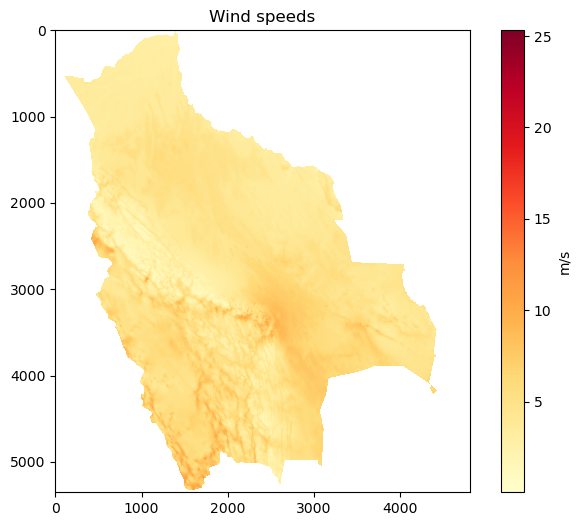

In [4]:
with rasterio.open(Path_All_resources) as src:
    data = src.read(1).astype(float)   # band 1
    data[data == src.nodata] = np.nan  # mask nodata

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="m/s")
ax.set_title("Wind speeds")
plt.show()

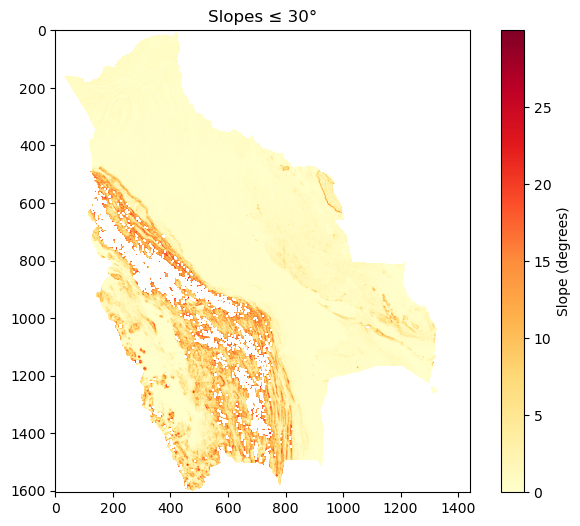

In [5]:
with rasterio.open(Path_Slope_map) as src2:
    slopes = src2.read(1).astype(float)
    nodata = src2.nodata

# Remove existing nodata first
slopes[slopes == nodata] = np.nan

# Mask out slopes above your threshold
threshold = 30  # degrees, adjust to your criteria
slopes[slopes > threshold] = np.nan

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(slopes, cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Slope (degrees)")
ax.set_title(f"Slopes ≤ {threshold}°")
plt.show()

The **slope** layer is one of the hard technical constraints in the MSR model: above a certain terrain slope, turbine/panel installation and access for construction/maintenance become impractical. Here we just visualize slopes up to a chosen `threshold` (30°) — the actual exclusion of steep terrain from the resource happens later, in the "Scoring data layers" section.

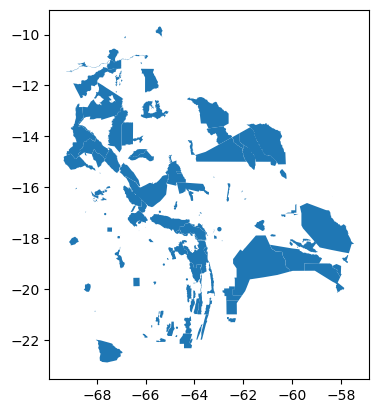

In [6]:
natural_reserves = gpd.read_file(Path_Natural_reserves)
natural_reserves.plot()
plt.show()

**Protected areas** (nature reserves, national parks, etc.) are a hard legal/environmental exclusion — regardless of resource quality, development is not permitted inside these polygons. This vector layer will be rasterized/masked against the resource grid further down.

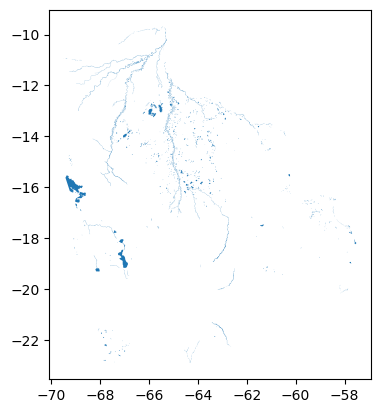

In [7]:
water_bodies = gpd.read_file(Path_Water_bodies)
water_bodies.plot()
plt.show()

**Water bodies** (lakes, rivers, large water surfaces) are excluded for the same reason as protected areas: they are not viable installation sites. This is the second vector exclusion layer that will be masked against the resource grid.

## Reproject everything to match

The resource/slope rasters are in an **equal-area projection** (`World_Mollweide`), which is what the MSR model uses so that pixel counts and areas (km²) are comparable across latitudes. The two exclusion shapefiles, however, come in **geographic coordinates (EPSG:4326, lat/lon)** — degrees, not meters, and not equal-area. Before we can rasterize/mask them against the resource grid, they must be reprojected into the raster's CRS so that a pixel and a polygon vertex refer to the same physical location.

In [8]:
print(natural_reserves.crs)

epsg:4326


In [9]:
print(water_bodies.crs)

epsg:4326


In [10]:
with rasterio.open(Path_Slope_map) as src2:
    print("Raster CRS:", src2.crs)


Raster CRS: PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [11]:
with rasterio.open(Path_All_resources) as src:
    print("Raster CRS:", src.crs)


Raster CRS: PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [12]:
natural_reserves = natural_reserves.to_crs(src.crs)
water_bodies = water_bodies.to_crs(src.crs)

## Scoring data layers

This is the heart of the MSR methodology, reproduced manually: starting from the gross resource raster, each constraint is applied **one at a time**, each producing a progressively smaller "available resource" map. The order doesn't change the final result (it's a series of independent AND-masks), but building it up incrementally makes clear exactly how much area each individual constraint removes — something the automated pipeline computes in one pass but doesn't show interactively.

The end state of this chain is conceptually equivalent to the toolset's **Suitable Resource Area** (Stage 2): everywhere left over after slope, protected areas, water bodies, and a minimum resource threshold have all been applied.

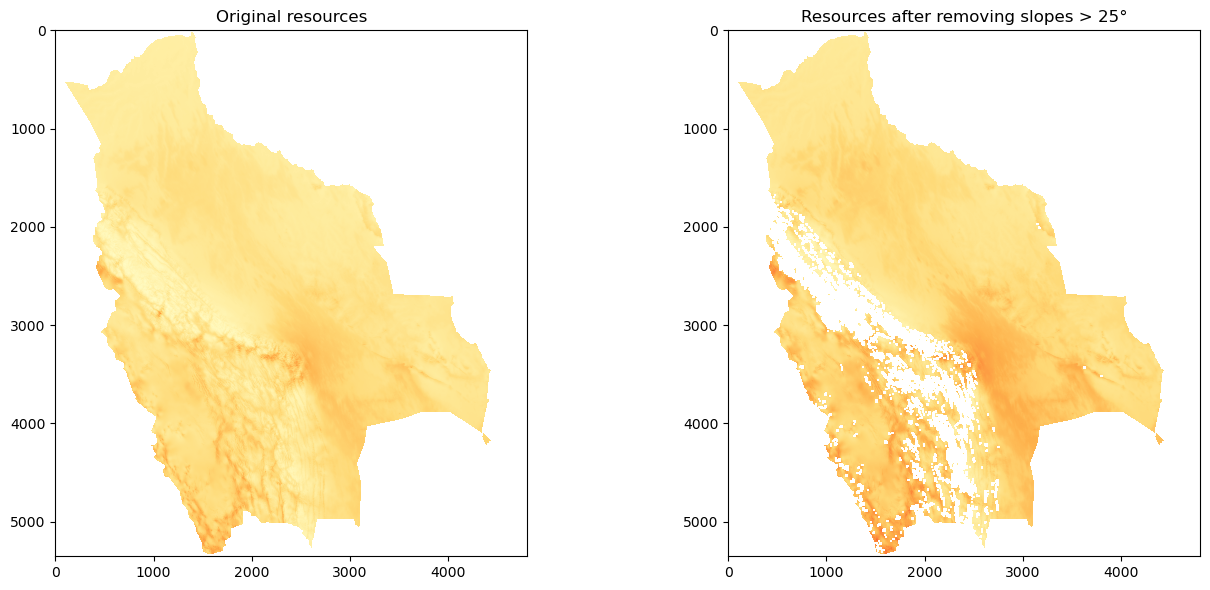

In [42]:
from rasterio.warp import reproject, Resampling

with rasterio.open(Path_All_resources) as src_res:
    resources = src_res.read(1).astype(float)
    resources[resources == src_res.nodata] = np.nan
    
    with rasterio.open(Path_Slope_map) as src_slope:

        # Create an empty array with the same shape as resources
        slopes_resampled = np.empty_like(resources)
        
        reproject(
            source=rasterio.band(src_slope, 1),
            destination=slopes_resampled,
            src_transform=src_slope.transform,
            src_crs=src_slope.crs,
            dst_transform=src_res.transform,
            dst_crs=src_res.crs,
            resampling=Resampling.nearest
        )


# Mask out high slope areas from resources
slope_threshold = 25
resources_filtered = resources.copy()
resources_filtered[slopes_resampled > slope_threshold] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources, cmap="YlOrRd")
axes[0].set_title("Original resources")

axes[1].imshow(resources_filtered, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes > {slope_threshold}°")

plt.tight_layout()
plt.show()

### Step 1 — Exclude steep slopes

The slope raster has a different resolution/grid than the resource raster, so it's **resampled onto the resource grid** first (`reproject` with nearest-neighbor, which is appropriate for this since slope is a categorical-like threshold decision, not something to interpolate smoothly). Any resource pixel whose corresponding slope exceeds `slope_threshold` (25°) is then set to `NaN` — i.e. removed from consideration entirely.

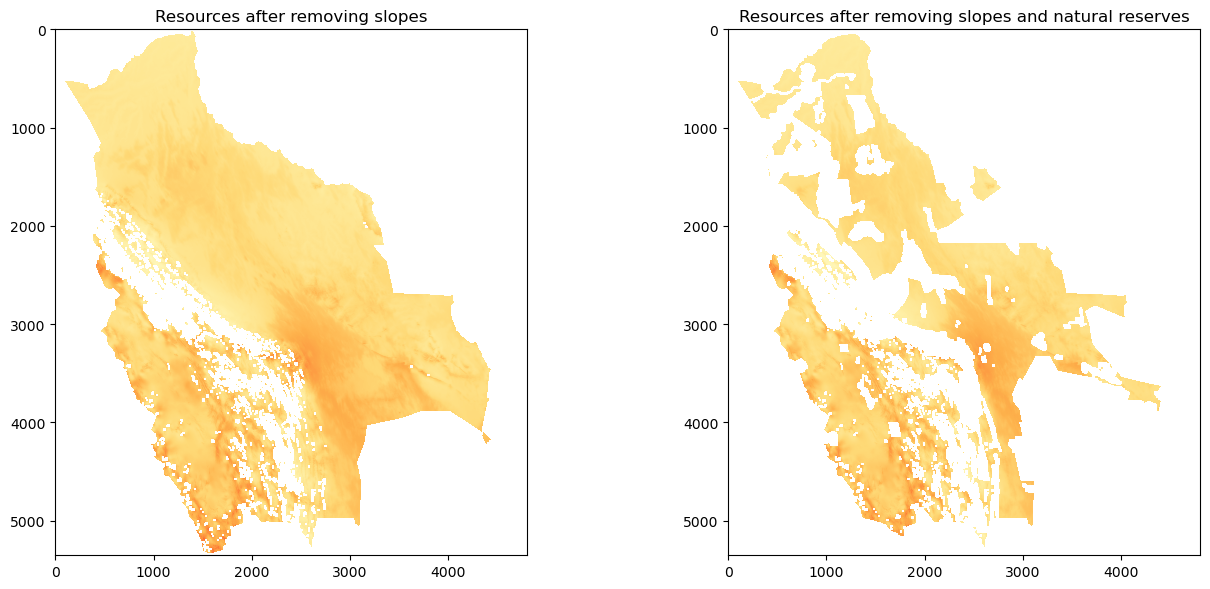

In [43]:
from rasterio.features import geometry_mask

with rasterio.open(Path_All_resources) as src_res:
    # Create a mask from the shapefile (True where polygons are)
    mask = geometry_mask(
        natural_reserves.geometry,
        transform=src_res.transform,
        invert=True,
        out_shape=(src_res.height, src_res.width)
    )

# Remove those regions from resources_filtered
resources_filtered_v2 = resources_filtered.copy()
resources_filtered_v2[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources_filtered, cmap="YlOrRd")
axes[0].set_title("Resources after removing slopes")

axes[1].imshow(resources_filtered_v2, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes and natural reserves")

plt.tight_layout()
plt.show()

### Step 2 — Exclude protected areas

`geometry_mask` rasterizes the protected-area polygons onto the resource grid: `invert=True` makes the mask `True` *inside* the polygons, so those pixels are the ones we blank out. This is the vector-to-raster exclusion step that the MSR Creator toolset performs internally when producing its `*_protected_areas_..._Scored.tif` layer — here it's collapsed into a binary in/out mask instead of a graded score, to make the exclusion itself explicit.

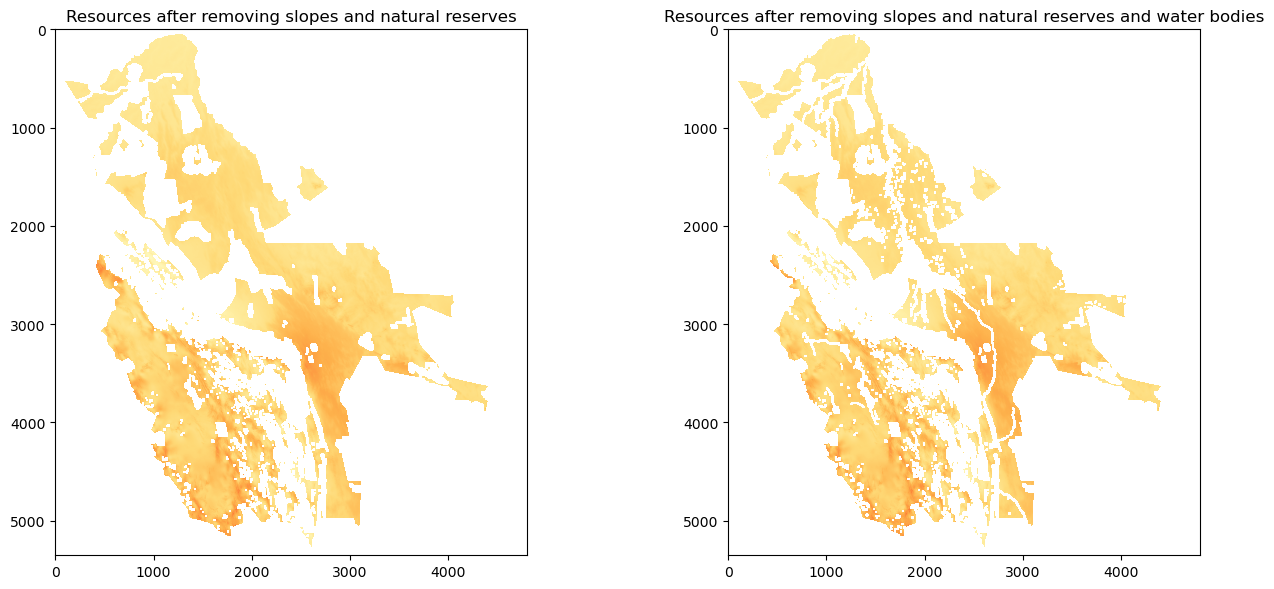

In [44]:
with rasterio.open(Path_All_resources) as src_res:
    # Create a mask from the shapefile (True where polygons are)
    mask = geometry_mask(
        water_bodies.geometry,
        transform=src_res.transform,
        invert=True,
        out_shape=(src_res.height, src_res.width)
    )

# Remove those regions from resources_filtered
resources_filtered_v3 = resources_filtered_v2.copy()
resources_filtered_v3[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources_filtered_v2, cmap="YlOrRd")
axes[0].set_title("Resources after removing slopes and natural reserves")

axes[1].imshow(resources_filtered_v3, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes and natural reserves and water bodies")

plt.tight_layout()
plt.show()

### Step 3 — Exclude water bodies

Same masking approach as the previous step, now applied to the water-bodies polygons and stacked on top of the slope + protected-area exclusion already applied. Each `_v2`, `_v3`, … array is a snapshot after one more constraint, so the two-panel plots let you see exactly what each additional exclusion removes.

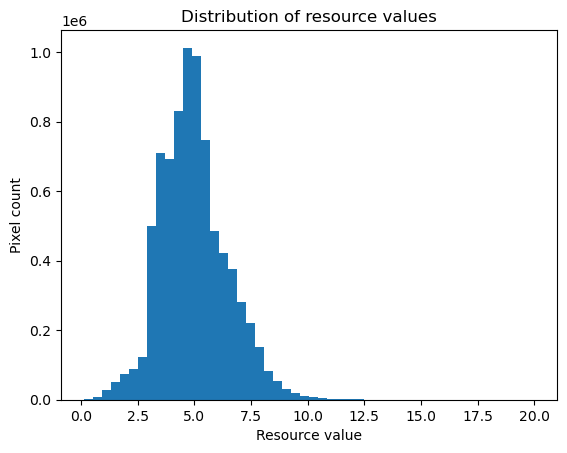

In [45]:
plt.hist(resources_filtered_v3[~np.isnan(resources_filtered_v3)], bins=50)
plt.xlabel("Resource value")
plt.ylabel("Pixel count")
plt.title("Distribution of resource values")
plt.show()

### Choosing a minimum resource threshold

After the hard exclusions (slope, protected areas, water bodies), what remains is a candidate area — but not all of it is economically worth developing. This histogram of the surviving resource values is used to visually pick a **minimum resource threshold**: the point below which wind speed (or irradiance) is too weak to be competitive. This is the same idea as the toolset's minimum-resource criterion that produces the **Suitable Resource Area**.

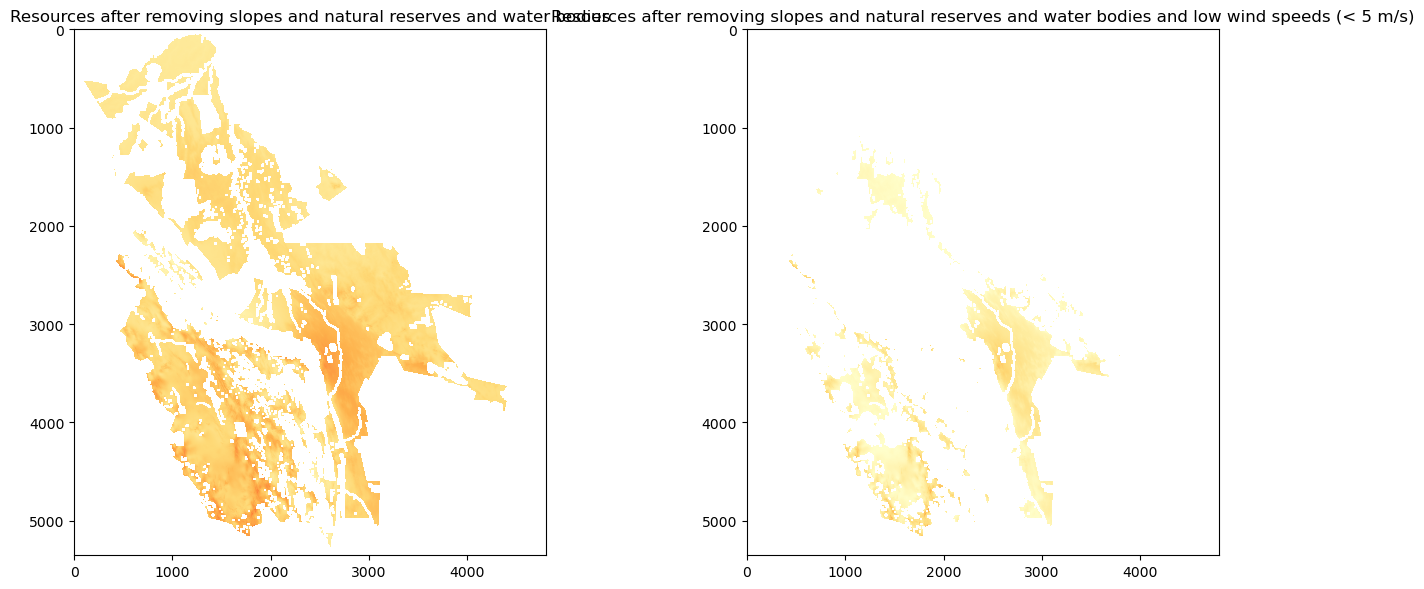

In [46]:
# Keep only high resource areas
threshold = 5  # adjust to your resource units

resources_filtered_v4 = resources_filtered_v3.copy()
resources_filtered_v4[resources_filtered_v4 < threshold] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources_filtered_v3, cmap="YlOrRd")
axes[0].set_title("Resources after removing slopes and natural reserves and water bodies")

axes[1].imshow(resources_filtered_v4, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes and natural reserves and water bodies and low wind speeds (< {threshold} m/s)")

plt.tight_layout()
plt.show()

### Step 4 — Apply the resource threshold

Pixels below `threshold` (here, 5 m/s) are dropped even though they survived all the spatial exclusions — they simply aren't a good enough resource to be worth developing. What's left in `resources_filtered_v4` is the fully-constrained, minimum-resource-qualifying area: this is the manual equivalent of the **Suitable Resource Area** raster produced by the automated pipeline.

In [ ]:
# Show the excluded low-resource areas (diagnostic only - does not affect resources_filtered_v4)
threshold = 5  # adjust to your resource units

low_wind_regions = resources.copy()
low_wind_regions[low_wind_regions > threshold] = np.nan

fig, axes = plt.subplots(figsize=(8, 6))

axes.imshow(low_wind_regions, cmap="YlOrRd")
axes.set_title(f"Low wind speeds regions (< {threshold} m/s)")

plt.tight_layout()
plt.show()

### The complementary view: where resource is too weak

This cell reruns the threshold logic in reverse, starting from the *unconstrained* `resources` array (not the exclusion-filtered chain) and keeping only values **below** the threshold. It's a diagnostic sanity check, not a pipeline step: it shows where wind speeds are simply too low, independent of slope/protected-area/water exclusions, so you can distinguish "excluded for spatial reasons" from "excluded for resource-quality reasons."

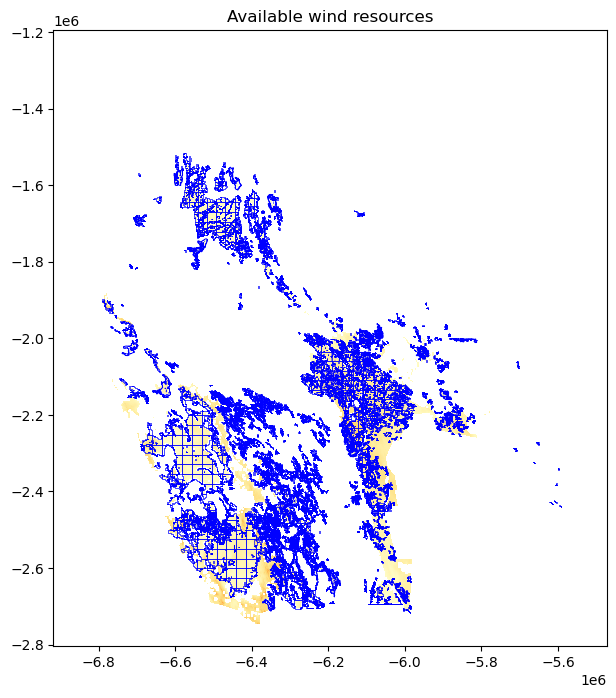

In [48]:
with rasterio.open(Path_All_resources) as src_res:
    msr_shapefile = gpd.read_file(Path_MSR_map).to_crs(src_res.crs)

fig, ax = plt.subplots(figsize=(10, 8))
show(resources_filtered_v4, transform=src_res.transform, ax=ax, cmap="YlOrRd")
msr_shapefile.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=0.5)
ax.set_title("Available wind resources")
plt.show()

### Final check — do the manual filters agree with the real MSRs?

As a validation step, the actual **Final MSR polygons** produced by the full automated pipeline are overlaid on top of our hand-built suitable-resource raster. Don't expect a perfect match — this manual walkthrough is a simplified stand-in for `MSR_Creator.py`, and several real differences will show up as the MSR boundaries not exactly tracing the filtered raster:

- **Missing exclusion criteria.** The real Stage 1 scoring also excludes on Population Density, Land Cover, and Elevation (capped at 4000 m for Bolivia), plus distance buffers to Roads and to the Transmission Grid — on top of slope, protected areas, and water bodies. This notebook only reproduces the latter three plus a resource cutoff, so it will always show *more* "suitable" area than the real pipeline allows.
- **Slope units mismatch.** `wind_slope_projected.tif` is computed as **percent grade**, not degrees (`rd.TerrainAttribute(..., attrib='slope_percentage')` in `MSR_Creator.py`). The plots above label and threshold it as if it were in degrees, which changes which pixels actually get excluded (25% grade ≈ 14°, while 25° ≈ 47% grade).
- **Arbitrary resource threshold.** `threshold = 5` was picked by eye from the histogram. The real pipeline uses a control-file-defined threshold that Stage 3's resource-sufficiency check can lower automatically per country to guarantee a minimum energy yield — so the cutoff actually used to generate `FinalMSRs.shp` may not be 5 at all.
- **Polygon-level post-processing.** After scoring, the real pipeline labels contiguous patches and drops any below a minimum contiguous area, while splitting any patch above a maximum area cap. A pixel-perfect suitable-resource raster still wouldn't produce identical polygon boundaries, because small scattered qualifying pixels are dropped and large blobs get subdivided.
- **Boundary/clipping differences.** The automated pipeline reprojects to EPSG:4326, clips exactly to the country polygon, then reprojects back to Mollweide before scoring. If the raw rasters read here aren't clipped identically, expect minor mismatches near the country border/coastline.

If you want the overlay to line up more closely, the biggest levers are adding the missing exclusion layers (elevation, land cover, population density, roads/grid distance) and fixing the slope units — those two are likely responsible for most of the visible gap.